In [36]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import numpy as np
from typing import List
import aplusml
from aplusml.models import Patient

# Patient properties + model predictions
PATH_TO_INPUT_FOLDER = '../ignore/secure/hcm/'
PATH_TO_OUTPUT_FOLDER = '../ignore/secure/hcm/output/'
PATH_TO_PATIENT_PROPERTIES = None #os.path.join(PATH_TO_INPUT_FOLDER, 'properties.csv')

# Workflows
PATH_TO_BASE_YAML = '../workflows/hcm_base.yaml'
PATH_TO_AI_YAML = '../workflows/hcm_ai.yaml'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# HCM Tutorial

We use APLUS to compare model-guided workflows for HCM.

We use two configuration files:
* `workflows/hcm_base.yaml` is the base workflow that we will use to model three workflows: current state, random, and optimistic.
* `workflows/hcm_ai.yaml` is the workflow that uses AI to guide the workflow.

### Base Workflow

Here, we print out the base workflow that we will slightly modify to model three workflows: current state, random, and optimistic.

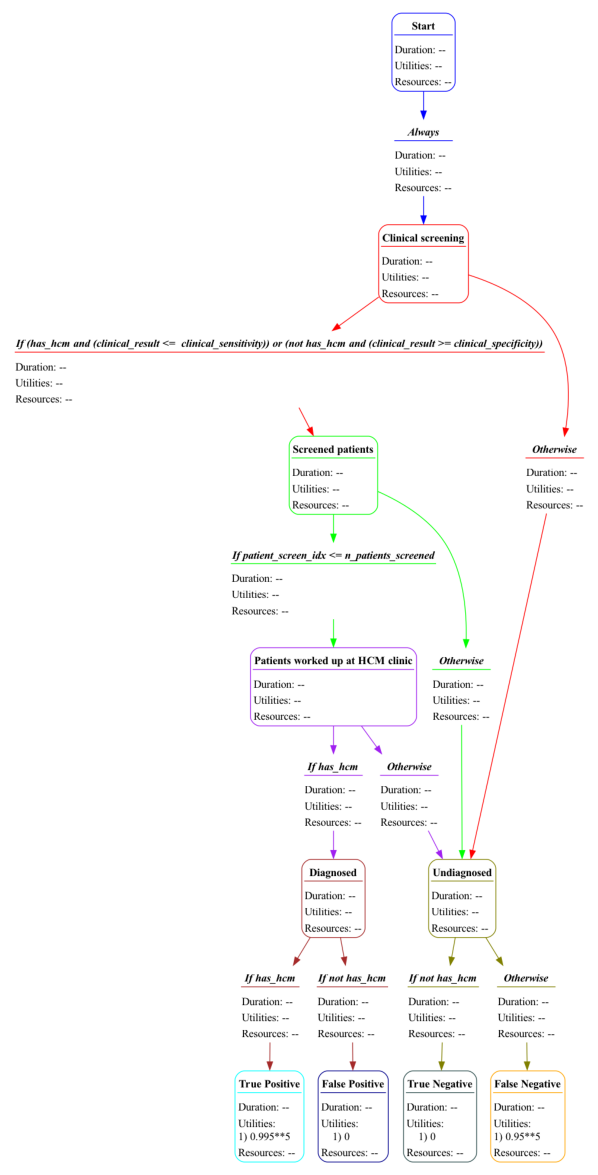

In [38]:
simulation = aplusml.load_simulation(PATH_TO_BASE_YAML, PATH_TO_PATIENT_PROPERTIES)
simulation.draw_workflow_diagram(figsize=(15,15))

In [39]:
simulation

self.metadata:
    - name: HCM (Base for random / current / optimistic)
    - path_to_properties: None
    - properties_col_for_patient_id: None
    - path_to_functions: None
    - patient_sort_preference_property: None

self.variables:
    - has_hcm: {'type': 'property', 'value': 'None'}
    - patient_screen_idx: {'type': 'property', 'value': 'None'}
    - clinical_result: {'type': 'property', 'distribution': 'uniform', 'start': 0, 'end': 1}
    - hcm_prevalence: {'type': 'scalar', 'value': '1/350'}
    - n_patients_screened: {'type': 'scalar', 'value': 1000}
    - clinical_sensitivity: {'type': 'scalar', 'value': 0.95}
    - clinical_specificity: {'type': 'scalar', 'value': 0.95}

self.states:
    - start
        - prescreen_patients
    - prescreen_patients
        - screen_patients
            if: (has_hcm and (clinical_result <=  clinical_sensitivity)) or (not has_hcm and (clinical_result >= clinical_specificity))
        - undiagnosed
    - screen_patients
        - visit_hcm_cli

In [40]:
def get_random() -> aplusml.Simulation:
    """Create a simulation for the "random" workflow"""
    simulation = aplusml.load_simulation(PATH_TO_BASE_YAML, PATH_TO_PATIENT_PROPERTIES)
    # ignore clinical pre-screening
    simulation.states['start'].transitions[0].dest = 'screen_patients'
    del simulation.states['prescreen_patients']
    # relabel
    simulation.states['screen_patients'].label = 'Randomly screened patients'
    return simulation

def get_optimistic() -> aplusml.Simulation:
    """Create a simulation for the "optimistic" workflow"""
    simulation = aplusml.load_simulation(PATH_TO_BASE_YAML, PATH_TO_PATIENT_PROPERTIES)
    # ignore clinical pre-screening AND HCM clinic capacity constraint
    simulation.states['start'].transitions[0].dest = 'visit_hcm_clinic'
    del simulation.states['prescreen_patients']
    del simulation.states['screen_patients']
    return simulation

def get_current() -> aplusml.Simulation:
    """Create a simulation for the "current" workflow"""
    simulation = aplusml.load_simulation(PATH_TO_BASE_YAML, PATH_TO_PATIENT_PROPERTIES)
    # relabel
    simulation.states['screen_patients'].label = 'Randomly chosen patients (post-clinical screening)'
    return simulation

#### Random Workflow

Let's see what the "random" version of the workflow looks like.

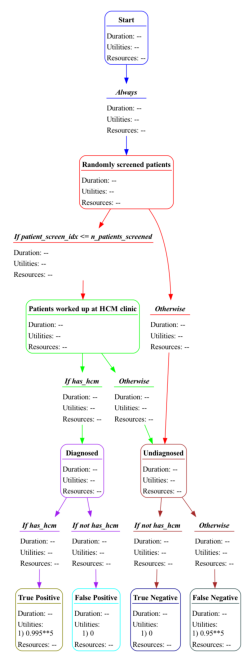

In [41]:
simulation = get_random()
simulation.draw_workflow_diagram(figsize=(3,20))

#### Optimistic Workflow

Let's see what the "optimistic" version of the workflow looks like.

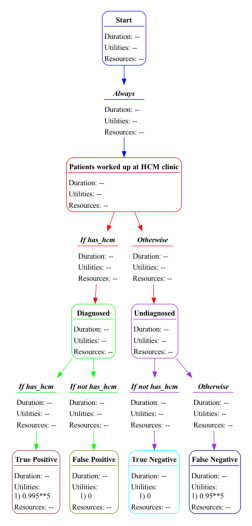

In [42]:
simulation = get_optimistic()
simulation.draw_workflow_diagram(figsize=(3,20))

#### Current Workflow

Let's see what the "current state" version of the workflow looks like.

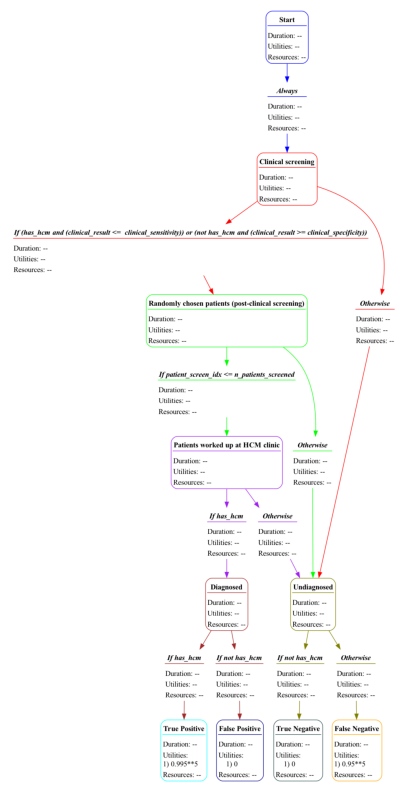

In [43]:
simulation = get_current()
simulation.draw_workflow_diagram(figsize=(5,20))

### AI-Guided Workflow

Let's now see what the "AI-guided" version of the workflow looks like.

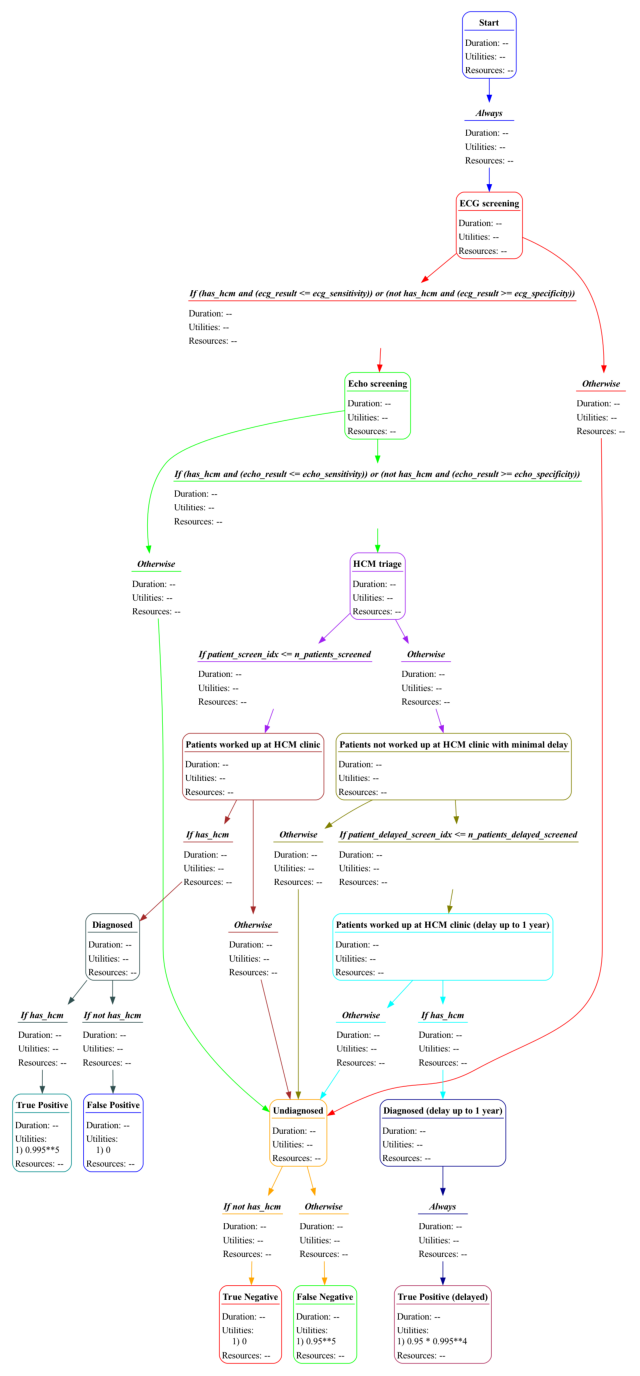

In [44]:
simulation = aplusml.load_simulation(PATH_TO_AI_YAML, PATH_TO_PATIENT_PROPERTIES)
simulation.draw_workflow_diagram(figsize=(8,20))

## Run Simulations

Now that we've defined the 4 versions of our workflow, we can run the APLUS simulation.

First, let's generate some synthetic patients to simulate patient flow through the workflow.

We make the following assumptions, based on interviews with key stakeholders:

#### Patient Flow
* We'll simulate one full year patient flow, so `NUM_DAYS = 365`
* Our total cohort size is 150K patients / yr
* Thus, each day on average we'll see $k \sim \text{Poisson}(150000 // 365)$ patients.

#### Disease Prevalence
* The prevalence of HCM is `HCM_PREVALENCE = 1/200`

#### HCM Clinic
* The HCM clinic (`state = visit_hcm_clinic`) is open 7 days a week and has daily capacity of `HCM_CLINIC_CAPACITY = 2`
* The HCM clinic (`state = visit_hcm_clinic`) has perfect accuracy for diagnosing HCM
* We assume that, if a patient cannot be seen by HCM clinic within a year, they are unlikely to be diagnosed with HCM in the next 5 years 

#### Echo Screening
* We assume that all patients can receive an echocardiogram in a relatively short time compared to the waiting time for the HCM clinic (weeks to months vs. months to over a year)

#### Utilities
Our main utility is the annual risk of HCM-related death for each patient.
* True Positives: Annual mortality = 0.5%
* False Negatives: Annual mortality = 2-5%
* True Negatives: Annual mortality = 0
* False Positives: Annual mortality = 0

In [45]:
np.random.seed(0)

# Simulation parameters
NUM_DAYS: int = 365
MEAN_PATIENTS_PER_DAY: int = 150_000 // 365
HCM_PREVALENCE: float = 1 / 200
HCM_CLINIC_CAPACITY: int = 2

# Sample # of patients per day
num_admits_per_day = np.random.poisson(lam=MEAN_PATIENTS_PER_DAY, size=NUM_DAYS)

# Random indexes for resource prioritization
screen_idxs: List[int] = list(range(MEAN_PATIENTS_PER_DAY * NUM_DAYS * 10))
np.random.shuffle(screen_idxs)
delayed_screen_idxs: List[int] = list(range(MEAN_PATIENTS_PER_DAY * NUM_DAYS * 10))
np.random.shuffle(delayed_screen_idxs)

patients: List[Patient] = []
# Generate patients for each day
for timestep, n_patients in enumerate(num_admits_per_day):
    for x in range(n_patients):
        # Generate patient properties
        properties = {
            'has_hcm' : np.random.rand() < HCM_PREVALENCE,
            'patient_screen_idx' : screen_idxs[len(patients)], # assign a unique random screen index to each patient
            'patient_delayed_screen_idx' : delayed_screen_idxs[len(patients)], # assign a unique random delayed screen index to each patient
        }
        patients.append(Patient(
            len(patients), # ID
            timestep, # Start timestep
            properties=properties,
        ))
print("# of patients: ", len(patients))
print("# of days: ", NUM_DAYS)
print("Mean # of patients per day: ", np.mean(num_admits_per_day))
print("HCM prevalence: ", np.mean([p.properties['has_hcm'] for p in patients]), "(expected prevalence =", HCM_PREVALENCE, ")")

# of patients:  149694
# of days:  365
Mean # of patients per day:  410.1205479452055
HCM prevalence:  0.005130466150947934 (expected prevalence = 0.005 )


Now, let's prepare the patients for the simulation.

In [47]:
patients = simulation.create_patients_for_simulation(patients, random_seed = 0)
patients[0]

{'id': 0, 'start_timestep': 0, 'properties': {'has_hcm': 'None', 'patient_screen_idx': 'None', 'patient_delayed_screen_idx': 'None', 'ecg_result': 0.5488135039273248, 'echo_result': 0.11711118906913687}, 'history': [], 'current_state': None}

## Run Simulation